In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("mbta_cleaned.csv", parse_dates=["date"])

df["route_name"] = df["route_name"].replace("Kingston Line", "Kingston/Plymouth Line")
df["route_name"] = df["route_name"].replace("Franklin Line", "Franklin/Foxboro Line")

df["year"] = df["date"].dt.year
df["total_passengers"] = df["average_ons"] + df["average_offs"]

# -----------------------------
# Visualization 1:
# Ridership trends over time by route
# -----------------------------
df_line = df.groupby(["year", "route_name"], as_index=False)["average_ons"].mean()
df_line = df_line.sort_values("year")

route_options = sorted(df_line["route_name"].unique())

route_dropdown = alt.binding_select(
    options=[None] + route_options,
    labels=["All Routes"] + route_options,
    name="Route: "
)

route_select = alt.selection_point(
    fields=["route_name"],
    bind=route_dropdown,
    value=[]
)

route_colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#aec7e8", "#98df8a"
]

line_chart = (
    alt.Chart(df_line)
    .mark_line(point=True)
    .encode(
        x=alt.X("year:O", title="Year", axis=alt.Axis(labelAngle=-45)),
        y=alt.Y("average_ons:Q", title="Average Passengers"),
        color=alt.Color(
            "route_name:N",
            legend=alt.Legend(title="Route"),
            scale=alt.Scale(domain=route_options, range=route_colors)
        ),
        opacity=alt.condition(route_select, alt.value(1.0), alt.value(0.1)),
        strokeWidth=alt.condition(route_select, alt.value(3), alt.value(1)),
        tooltip=[
            alt.Tooltip("year:O", title="Year"),
            alt.Tooltip("route_name:N", title="Route"),
            alt.Tooltip("average_ons:Q", title="Avg Passengers", format=".2f")
        ]
    )
    .add_params(route_select)
    .properties(
        width=700,
        height=400,
        title="MBTA Commuter Rail Ridership Trends Over Time"
    )
)

line_chart
line_chart.save("charts/line_chart.html")

FileNotFoundError: [Errno 2] No such file or directory: 'charts\\line_chart.html'

In [ ]:
# -----------------------------
# Visualization 2:
# Heatmap of average passengers on board by hour and route
# -----------------------------
df_heat = df.groupby(["route_name", "hour"], as_index=False)["average_load"].mean()

heatmap = (
    alt.Chart(df_heat)
    .mark_rect()
    .encode(
        x=alt.X("hour:O", title="Hour of Day"),
        y=alt.Y("route_name:N", title="Route"),
        color=alt.Color(
            "average_load:Q",
            title="Avg Passengers On Board",
            scale=alt.Scale(scheme="blues")
        ),
        tooltip=[
            alt.Tooltip("route_name:N", title="Route"),
            alt.Tooltip("hour:O", title="Hour"),
            alt.Tooltip("average_load:Q", title="Avg Passengers", format=".1f")
        ]
    )
    .properties(
        width=700,
        height=350,
        title="MBTA Commuter Rail Average Passengers On Board by Hour and Route"
    )
)

heatmap
heatmap.save("charts/heatmap.html")

C:\Users\msfio\AppData\Local\Temp\ipykernel_18972\449260871.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




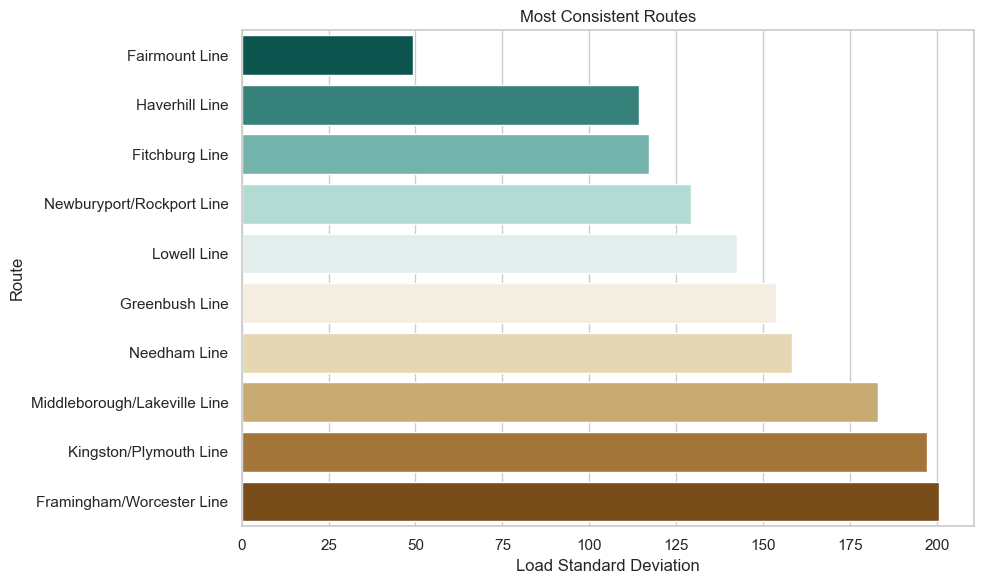

In [ ]:
# -----------------------------
# Visualization 3:
# Most consistent routes
# -----------------------------
consistency = df.groupby("route_name")["average_load"].std().reset_index()
consistency = consistency.sort_values("average_load").head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=consistency,
    y="route_name",
    x="average_load",
    palette="BrBG_r"
)
plt.title("Most Consistent Routes")
plt.xlabel("Load Standard Deviation")
plt.ylabel("Route")


plt.tight_layout()
plt.savefig("charts/consistency.png")
plt.show()

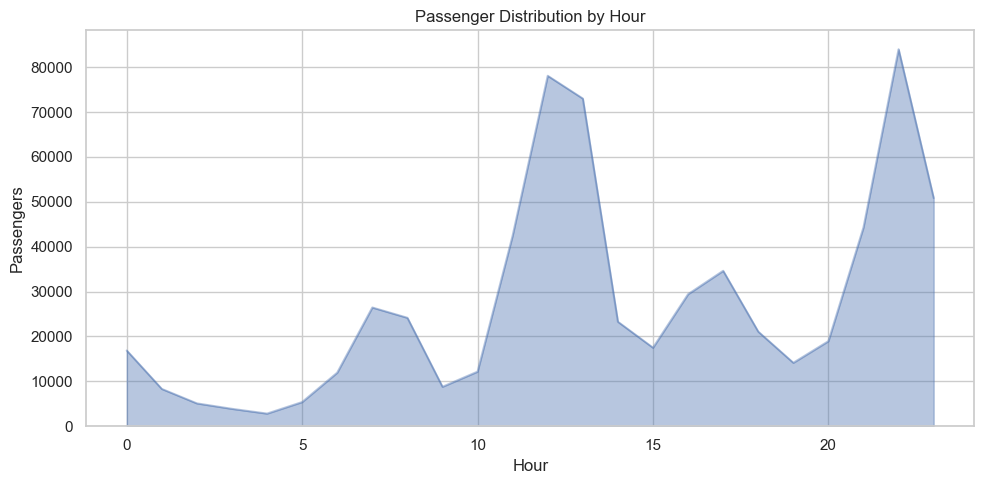

In [ ]:
# -----------------------------
# Visualization 4:
# Passenger distribution by hour
# -----------------------------
hourly = df.groupby("hour")["total_passengers"].sum().sort_index()

plt.figure(figsize=(10, 5))
hourly.plot(kind="area", alpha=0.4)
plt.title("Passenger Distribution by Hour")
plt.xlabel("Hour")
plt.ylabel("Passengers")
plt.tight_layout()
plt.savefig("charts/hourly_area.png")
plt.show()

In [ ]:
# -----------------------------
# Visualization 5:
# Sankey diagram: Day Type -> Route -> Time of Day
# -----------------------------
def hour_bucket(hour):
    if 5 <= hour <= 9:
        return "Morning"
    elif 10 <= hour <= 14:
        return "Midday"
    elif 15 <= hour <= 19:
        return "Evening"
    else:
        return "Night"

df["time_bucket"] = df["hour"].apply(hour_bucket)

top_routes = (
    df.groupby("route_name")["total_passengers"]
    .sum()
    .nlargest(8)
    .index
)

df_sankey = df[df["route_name"].isin(top_routes)].copy()

flow1 = (
    df_sankey.groupby(["day_type_name", "route_name"], as_index=False)["total_passengers"]
    .sum()
    .rename(columns={
        "day_type_name": "source",
        "route_name": "target",
        "total_passengers": "value"
    })
)

flow2 = (
    df_sankey.groupby(["route_name", "time_bucket"], as_index=False)["total_passengers"]
    .sum()
    .rename(columns={
        "route_name": "source",
        "time_bucket": "target",
        "total_passengers": "value"
    })
)

flows = pd.concat([flow1, flow2], ignore_index=True)

labels = pd.unique(flows[["source", "target"]].values.ravel())
label_to_index = {label: i for i, label in enumerate(labels)}

flows["source_id"] = flows["source"].map(label_to_index)
flows["target_id"] = flows["target"].map(label_to_index)

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=list(labels)
    ),
    link=dict(
        source=flows["source_id"],
        target=flows["target_id"],
        value=flows["value"]
    )
)])

fig.update_layout(
    title_text="MBTA Passenger Flow: Day Type to Route to Time of Day",
    font_size=12,
    width=1000,
    height=600
)

fig.show()

fig.write_html("charts/sankey.html")

In [4]:
import plotly.express as px
import pandas as pd
import plotly.express as px

# LOAD DATA
df = pd.read_csv("mbta_cleaned.csv", parse_dates=["date"])

# recreate this column (important)
df["total_passengers"] = df["average_ons"] + df["average_offs"]
# aggregate data
hourly = df.groupby("hour")["total_passengers"].sum().reset_index()

# create interactive bar chart
fig_hourly = px.bar(
    hourly,
    x="hour",
    y="total_passengers",
    title="Passenger Distribution by Hour",
    labels={"hour": "Hour of Day", "total_passengers": "Total Passengers"},
)

fig_hourly.show()

# SAVE AS HTML
fig_hourly.write_html("project-folder/charts/hourly_bar.html")

In [7]:
import json

# aggregate data
hourly = df.groupby("hour")["total_passengers"].sum().reset_index()

# convert to JSON
hourly_json = hourly.to_dict(orient="records")

# save JSON to file
with open("project-folder/charts/hourly_data.json", "w") as f:
    json.dump(hourly_json, f)

In [20]:
import os
import json

os.makedirs("charts", exist_ok=True)

# make sure df exists
# if needed, uncomment these:
# import pandas as pd
# df = pd.read_csv("mbta_cleaned.csv", parse_dates=["date"])
# df["total_passengers"] = df["average_ons"] + df["average_offs"]

hourly = df.groupby("hour", as_index=False)["total_passengers"].sum()
hourly_json = json.dumps(hourly.to_dict(orient="records"))

html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <title>D3 Passenger Distribution by Hour</title>
  <script src="https://d3js.org/d3.v7.min.js"></script>
  <style>
    body {{
      margin: 0;
      font-family: Arial, sans-serif;
      background: white;
    }}

    .chart-title {{
      font-size: 22px;
      font-weight: bold;
      text-anchor: middle;
      fill: #243b6b;
    }}

    .axis-label {{
      font-size: 15px;
      font-weight: 600;
      fill: #333;
    }}

    .bar {{
      fill: steelblue;
    }}

    .bar:hover {{
      fill: orange;
    }}

    .tooltip {{
      position: absolute;
      background: rgba(255,255,255,0.97);
      border: 1px solid #ccc;
      border-radius: 8px;
      padding: 8px 10px;
      font-size: 13px;
      pointer-events: none;
      opacity: 0;
      box-shadow: 0 2px 8px rgba(0,0,0,0.15);
    }}
  </style>
</head>
<body>
  <div id="tooltip" class="tooltip"></div>
  <svg width="900" height="520"></svg>

  <script>
    const data = {hourly_json};

    const svg = d3.select("svg");
    const tooltip = d3.select("#tooltip");

    const margin = {{ top: 70, right: 30, bottom: 90, left: 100 }};
    const width = 900 - margin.left - margin.right;
    const height = 520 - margin.top - margin.bottom;

    const g = svg.append("g")
      .attr("transform", `translate(${{margin.left}},${{margin.top}})`);

    data.forEach(d => {{
      d.hour = +d.hour;
      d.total_passengers = +d.total_passengers;
    }});

    const x = d3.scaleBand()
      .domain(data.map(d => d.hour))
      .range([0, width])
      .padding(0.2);

    const y = d3.scaleLinear()
      .domain([0, d3.max(data, d => d.total_passengers)])
      .nice()
      .range([height, 0]);

    g.append("text")
      .attr("class", "chart-title")
      .attr("x", width / 2)
      .attr("y", -30)
      .text("Passenger Distribution by Hour");

    g.append("g")
      .attr("transform", `translate(0,${{height}})`)
      .call(d3.axisBottom(x).tickFormat(d3.format("d")));

    g.append("g")
      .call(d3.axisLeft(y));

    g.append("text")
      .attr("class", "axis-label")
      .attr("x", width / 2)
      .attr("y", height + 60)
      .attr("text-anchor", "middle")
      .text("Hour of Day");

    g.append("text")
      .attr("class", "axis-label")
      .attr("transform", "rotate(-90)")
      .attr("x", -height / 2)
      .attr("y", -75)
      .attr("text-anchor", "middle")
      .text("Total Passengers");

    g.selectAll(".bar")
      .data(data)
      .enter()
      .append("rect")
      .attr("class", "bar")
      .attr("x", d => x(d.hour))
      .attr("y", d => y(d.total_passengers))
      .attr("width", x.bandwidth())
      .attr("height", d => height - y(d.total_passengers))
      .on("mousemove", function(event, d) {{
        tooltip
          .style("opacity", 1)
          .html(`<strong>Hour:</strong> ${{d.hour}}<br><strong>Total Passengers:</strong> ${{Math.round(d.total_passengers)}}`)
          .style("left", (event.pageX + 12) + "px")
          .style("top", (event.pageY - 28) + "px");
      }})
      .on("mouseleave", function() {{
        tooltip.style("opacity", 0);
      }});
  </script>
</body>
</html>
"""

with open("project-folder/charts/d3_hourly_bar.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Saved real-data D3 chart to charts/d3_hourly_bar.html")

Saved real-data D3 chart to charts/d3_hourly_bar.html


In [ ]:
import plotly.express as px

df["total_passengers"] = df["average_ons"] + df["average_offs"]

# aggregate
route_hour = df.groupby(
    ["route_name", "hour"]
)["total_passengers"].sum().reset_index()

route_hour = route_hour[route_hour["total_passengers"] > 0]

# create treemap
fig = px.treemap(
    route_hour,
    path=["route_name", "hour"],
    values="total_passengers",
    color="total_passengers",
    title="Passenger Distribution by Route and Hour"
)

fig.show()

fig.write_html("project-folder/charts/treemap.html")